### **Gradient descent 3d Visualisation**

In [3]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plot
import numpy as np

In [11]:

x,y = make_regression(
    n_samples=100, 
    n_features=1, 
    n_informative=1, 
    n_targets=1,
    noise=20,
    random_state=10
)

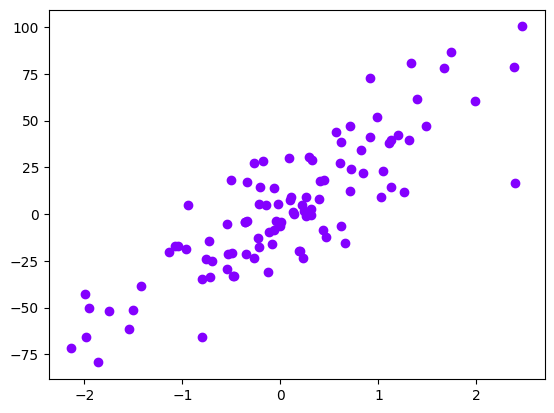

In [12]:
plot.scatter(x,y, color="#8400ff")

In [14]:
m_arr = np.linspace(-150, 150, 10)
b_arr = np.linspace(-150, 150, 10)
mGrid, bGrid = np.meshgrid(m_arr,b_arr)

final = np.vstack((mGrid.ravel().reshape(1,100),bGrid.ravel().reshape(1,100))).T

z_arr = []

for i in range(final.shape[0]):
    z_arr.append(np.sum((y - final[i,0]*x.reshape(100) - final[i,1])**2))

z_arr = np.array(z_arr).reshape(10,10)

In [17]:
import plotly.graph_objects as go
import plotly.io as pio

fig = go.Figure(data=[go.Surface(x = m_arr, y = b_arr, z =z_arr)])

fig.update_layout(title='Loss Function', autosize=False,
                  width=500, height=500,
                  margin=dict(l=65, r=50, b=65, t=90))

pio.renderers.default = "vscode"
fig.show()

In [20]:
b = 150
m = -127.82
lr = 0.001
all_b = []
all_m = []
all_cost = []

epochs = 30

for i in range(epochs):
    slope_b = 0
    slope_m = 0
    cost = 0
    for j in range(x.shape[0]):
        slope_b = slope_b - 2*(y[j] - (m * x[j]) -  b)
        slope_m = slope_m - 2*(y[j] - (m * x[j]) -  b)*x[j]
        cost = cost + (y[j] - m * x[j] -b) ** 2

    b = b - (lr * slope_b)
    m = m - (lr * slope_m)
    all_b.append(b)
    all_m.append(m)
    all_cost.append(cost)

In [21]:
import plotly.express as px

fig = px.scatter_3d(x=np.array(all_m).ravel(), y=np.array(all_b).ravel(), z=np.array(all_cost).ravel()*100)

fig.add_trace(go.Surface(x = m_arr, y = b_arr, z =z_arr*100 ))
pio.renderers.default = "vscode"
fig.show()

In [22]:
import plotly.graph_objects as go

fig = go.Figure(go.Scatter(x=np.array(all_m).ravel(), y=np.array(all_b).ravel(), name='High 2014',
                         line=dict(color='#fff', width=4)))

fig.add_trace(go.Contour(z=z_arr,x=m_arr,y=b_arr))

pio.renderers.default = "vscode"
fig.show()